In [64]:
def peak_pos_cms2( unmod_seq: str, crosslinker_position: int ) -> list:
    """
    determines the positions of all potential normal and xl fragments within the vector generated by generate_annotation_matrix

    This fuction is used only for cleavable crosslinked peptides  

    :param unmod_seq: Un modified peptide sequence
    :crosslinker_position: The position of crosslinker
    :return: position of diffrent fragments as list 
    """

    if len(unmod_seq) < 30:
        peaks_range = range(0, ((len(unmod_seq) - 1) * 2 * 3))   # position of all normal and xl-short fragments
        #peaks_y = 
        #peaks_b =  

        peaks_ylong = []
        if crosslinker_position != 1:
            peaks_b = np.array([3, 4, 5])
            peaks_b = np.tile(peaks_b, crosslinker_position - 1) + np.repeat(np.arange(crosslinker_position - 1) * 6, 3)
            first_pos_ylong = ((len(unmod_seq) - crosslinker_position) * 6) + 174   # fisrt  position for ylong
            peaks_ylong = np.arange(first_pos_ylong, first_pos_ylong + 3)
            peaks_ylong = np.tile(peaks_ylong, crosslinker_position - 1) + np.repeat(np.arange(crosslinker_position - 1) * 6, 3)
            
                
        peaks_blong = []
        if len(unmod_seq) != crosslinker_position:
            first_pos_blong = ((crosslinker_position - 1) * 6) + 174 + 3   # fisrt  position for blong
            peaks_y= [0, 1, 2]
            peaks_blong = [first_pos_blong, first_pos_blong + 1, first_pos_blong + 2]
            for j in range(1, (len(unmod_seq) - crosslinker_position)):
                peaks_blong += [first_pos_blong + (6 * j),
                                 (first_pos_blong + 1) + (6 * j),
                                 (first_pos_blong + 2) + (6 * j)]
                
                peaks_y += [(6 * j), (6 * j) + 1, (6 * j) + 2]
                
        peaks_range = list(peaks_range) + peaks_ylong  + peaks_blong   #all peaks range  
    else:
        peaks_range = range(0, ((constants.SEQ_LEN - 1) * 6 * 2))
    
    peaks_yshort = [x - 174 for x in peaks_ylong]
    peaks_bshort = [x - 174 for x in peaks_blong]
     

    available_peaks = list([index for index in peaks_range])
    available_peaks.sort()
    
    return available_peaks, peaks_y, peaks_b, peaks_yshort, peaks_bshort, peaks_ylong, peaks_blong    
   

In [65]:
peak_pos_cms2("PDKTDM", 2)

ValueError: operands could not be broadcast together with shapes (30,) (3,) 

In [66]:
import numpy as np

crosslinker_position = 3
unmod_seq = "PDKTDMKKDT"

first_pos_ylong = ((len(unmod_seq) - crosslinker_position) * 6) + 174
peaks_b = np.array([3, 4, 5])
peaks_ylong = np.arange(first_pos_ylong, first_pos_ylong + 3)

peaks_ylong = np.tile(peaks_ylong, crosslinker_position - 1) + np.repeat(np.arange(crosslinker_position - 1) * 6, 3)
peaks_b = np.tile(peaks_b, crosslinker_position - 1) + np.repeat(np.arange(crosslinker_position - 1) * 6, 3)

print(peaks_b)
print(peaks_ylong)


[ 3  4  5  9 10 11]
[216 217 218 222 223 224]


In [233]:
def peak_pos_cms2_new( unmod_seq: str, crosslinker_position: int ) -> list:
    """
    determines the positions of all potential normal and xl fragments within the vector generated by generate_annotation_matrix

    This fuction is used only for cleavable crosslinked peptides  

    :param unmod_seq: Un modified peptide sequence
    :crosslinker_position: The position of crosslinker
    :return: position of diffrent fragments as list 
    """
    peaks_y = []
    peaks_b = []
    peaks_yshort = []
    peaks_bshort = []
    peaks_ylong = []
    peaks_blong = []

    if len(unmod_seq) < 31  :
        if crosslinker_position != 1:
            peaks_b = np.array([3, 4, 5])
            peaks_b = np.tile(peaks_b, crosslinker_position - 1) + np.repeat(np.arange(crosslinker_position - 1) * 6, 3)
            first_pos_ylong = ((len(unmod_seq) - crosslinker_position) * 6) + 174   # fisrt  position for ylong
            peaks_ylong = np.arange(first_pos_ylong, first_pos_ylong + 3)
            peaks_ylong = np.tile(peaks_ylong, crosslinker_position - 1) + np.repeat(np.arange(crosslinker_position - 1) * 6, 3)

        if len(unmod_seq) != crosslinker_position:
            peaks_y= [0, 1, 2]
            peaks_y = np.tile(peaks_y, len(unmod_seq)-crosslinker_position) + np.repeat(np.arange(len(unmod_seq)-crosslinker_position) * 6, 3)
            first_pos_blong = ((crosslinker_position - 1) * 6) + 174 + 3   # fisrt  position for blong
            peaks_blong = [first_pos_blong, first_pos_blong + 1, first_pos_blong + 2]
            peaks_blong = np.arange(first_pos_blong, first_pos_blong + 3)
            peaks_blong = list(np.tile(peaks_blong, len(unmod_seq) - crosslinker_position) + np.repeat(np.arange(len(unmod_seq) - crosslinker_position) * 6, 3))
                
        peaks_yshort = [x - 174 for x in peaks_ylong]
        peaks_bshort = [x - 174 for x in peaks_blong]
        peaks_range = list(peaks_y) + list(peaks_b) + list(peaks_yshort) + list(peaks_bshort) + list(peaks_ylong) + list(peaks_blong)  
        peaks_range.sort()
        
    else:
        raise ValueError("Peptides exceeding a length of 30 are not supported")
        
    return peaks_range, peaks_y, peaks_b, peaks_yshort, peaks_bshort, peaks_ylong, peaks_blong    

In [237]:
peak_pos_cms2_new("PDTDK", 2)[0]

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 183,
 184,
 185,
 189,
 190,
 191,
 192,
 193,
 194,
 195,
 196,
 197]

In [241]:
#lst = 
indices = range(2, 348, 3)
#lst[indices] = -1
print(indices)

range(2, 348, 3)


In [1]:
def annotate_spectra(un_annot_spectra: str, xl: bool = False) :
    if xl:
        print("test")
    else:
        print("ff")
    return un_annot_spectra
    

result = annotate_spectra("ss")

ff


In [2]:
import spectrum_fundamentals.constants as constants
import spectrum_fundamentals.fragments as fragments
import spectrum_fundamentals.annotation as annotation
import spectrum_fundamentals.annotation as annotation
from oktoberfest.ce_calibration import CeCalibration
from spectrum_io.search_result.plink2 import Plink2
import spectrum_io.search_result as search_result
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import pandas as pd
from pathlib import Path
#from ce_calibration_module import CeCalibration

search_path = "/home/mkalhor/wilhelmlab/notebooks/filtered_data_1.csv"
df_search = Plink2.read_result(search_path)
#display(df_search)
raw_path = "/home/mkalhor/wilhelmlab/notebooks/Lumos_RSLC8_steppedHCD_SEC_F2.raw"
#raw_path = Path(raw_path)  # Convert raw_path to Path object
config_path = "/home/mkalhor/wilhelmlab/notebooks/config.json"
out_path = "/home/mkalhor/wilhelmlab/notebooks"


#print(df_search.columns)
calibration = CeCalibration(search_path, raw_path, out_path, config_path, mzml_reader_package = "pyteomics")
df_annotated_spectra, df_join  = calibration.gen_lib(df_search=df_search)


2023-07-03 14:42:57,286 - INFO - spectrum_io.search_result.plink2::read_result Reading csv_file file
2023-07-03 14:42:57,315 - INFO - spectrum_io.search_result.plink2::read_result Finished reading csv_file file
2023-07-03 14:42:57,332 - INFO - spectrum_io.search_result.plink2::update_columns_for_prosit Converting Plink2 peptide sequence to internal format
2023-07-03 14:42:57,359 - INFO - spectrum_io.search_result.plink2::update_columns_for_prosit Converting MaxQuant peptide sequence to internal format
2023-07-03 14:42:57,492 - INFO - spectrum_io.search_result.plink2::filter_valid_prosit_sequences #sequences before filtering for valid prosit sequences: 1208
2023-07-03 14:42:57,507 - INFO - spectrum_io.search_result.plink2::filter_valid_prosit_sequences #sequences after filtering for valid prosit sequences: 1127
2023-07-03 14:42:57,509 - INFO - oktoberfest.utils.config::read Reading configuration from /home/mkalhor/wilhelmlab/notebooks/config.json
2023-07-03 14:42:57,512 - INFO - oktober

KeyError: 'MODIFIED_SEQUENCE'

[-1.00000000e+00 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00
 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00
 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00
 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00
 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00
 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00
 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00
 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00
 -1.00000000e+00  6.42959521e+03  3.00350610e+03 -1.00000000e+00
 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00  1.54585693e+04
  4.29305322e+03 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00
 -1.00000000e+00  1.07403174e+04  4.36509277e+03 -1.00000000e+00
 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00  8.77860254e+03
  7.94287354e+03 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00
 -1.00000000e+00  2.64893823e+03  8.70949707e+03 -1.00000000e+00
 -1.00000000e+00 -1.00000

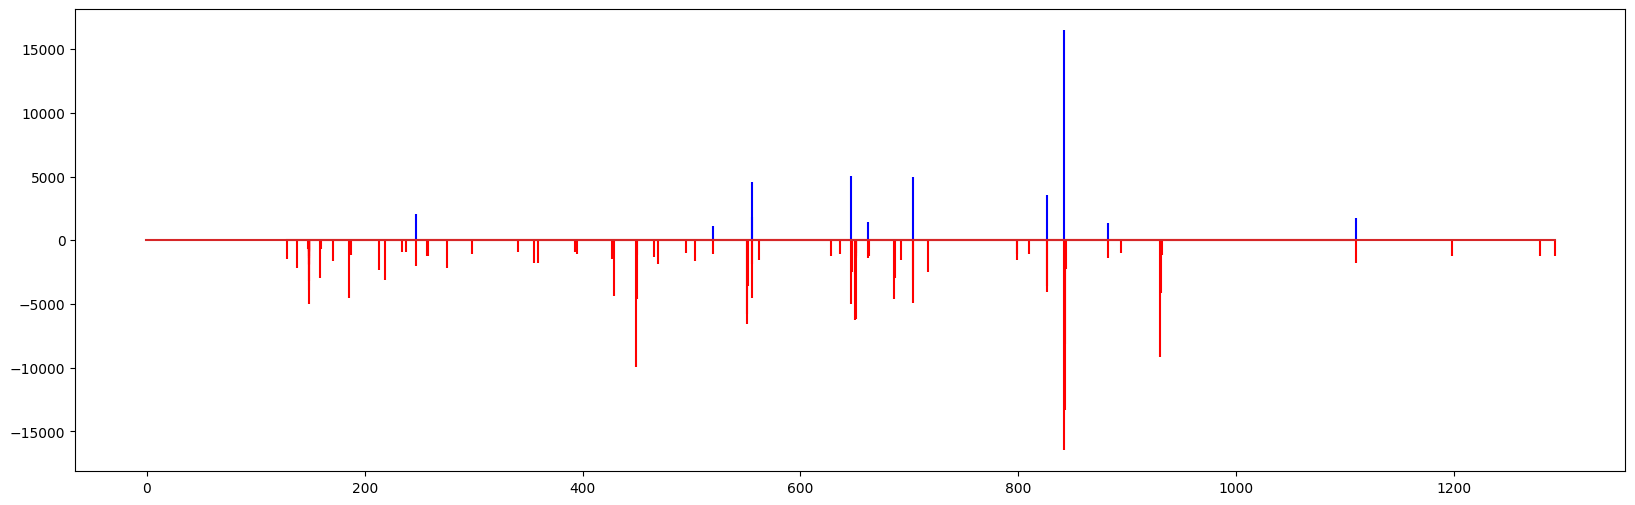

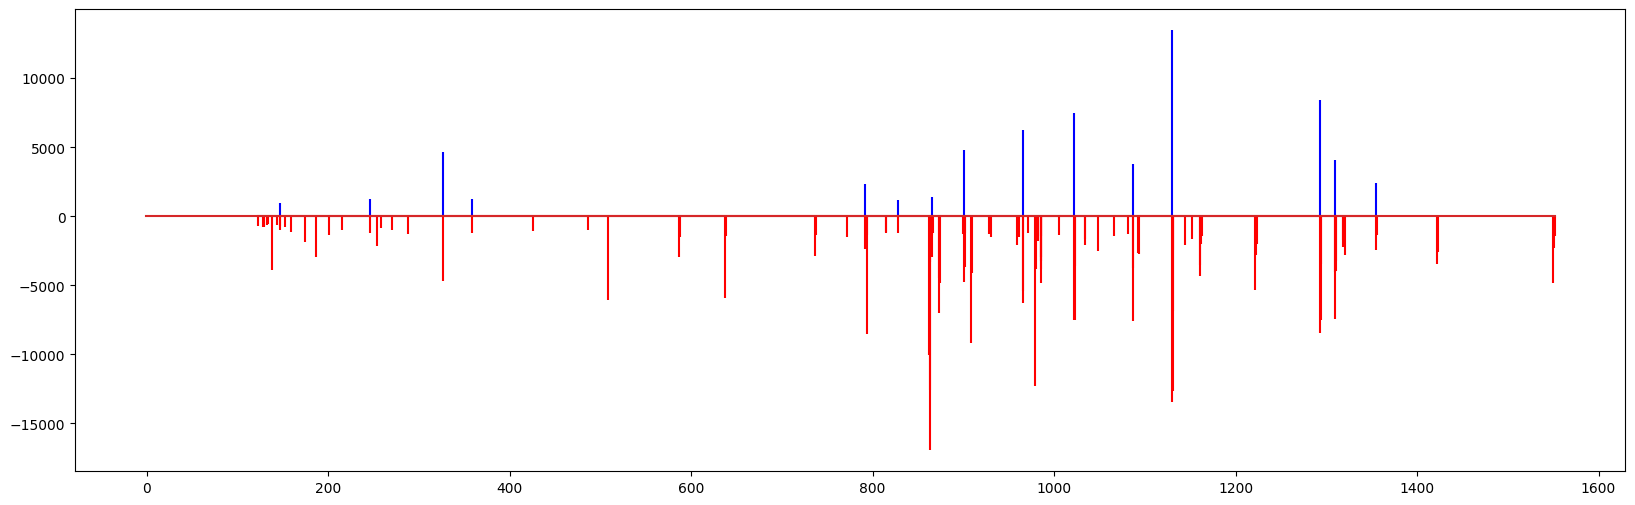

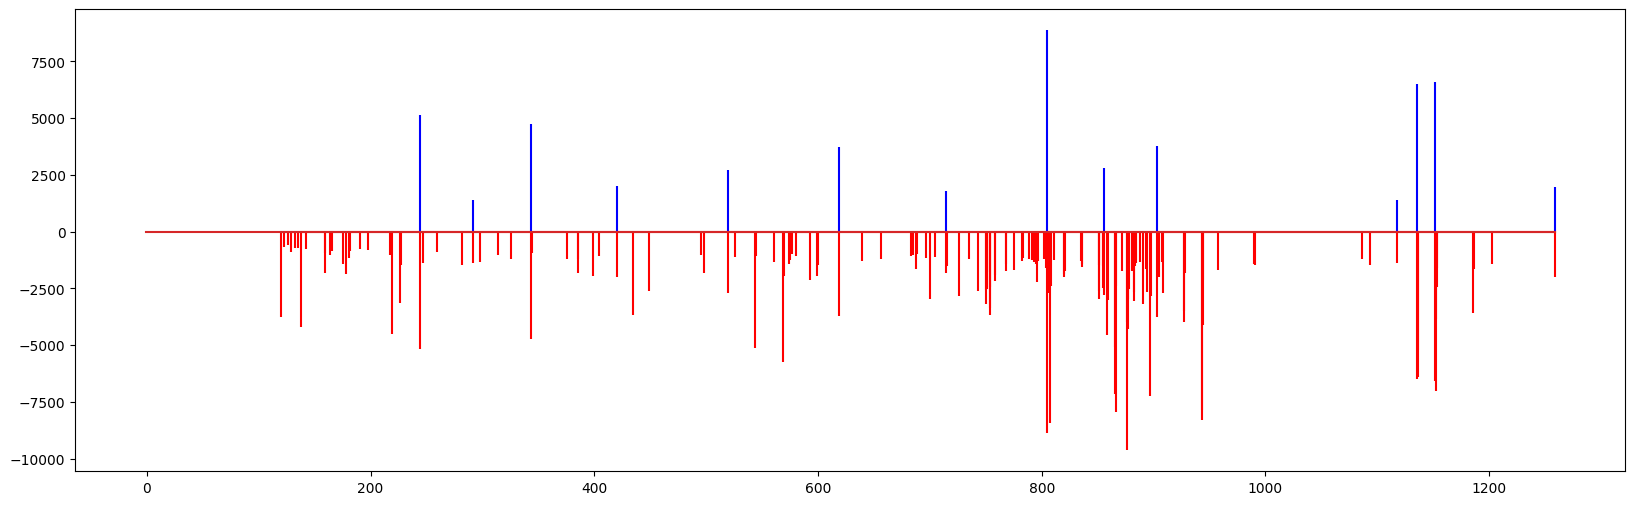

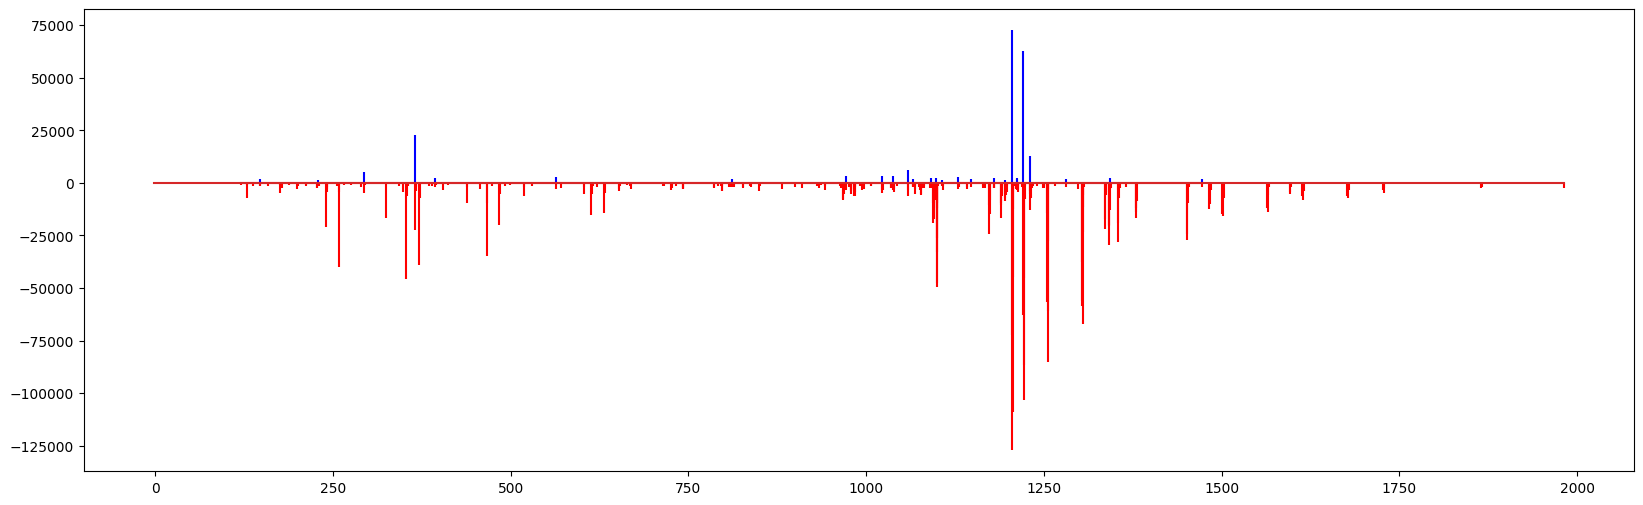

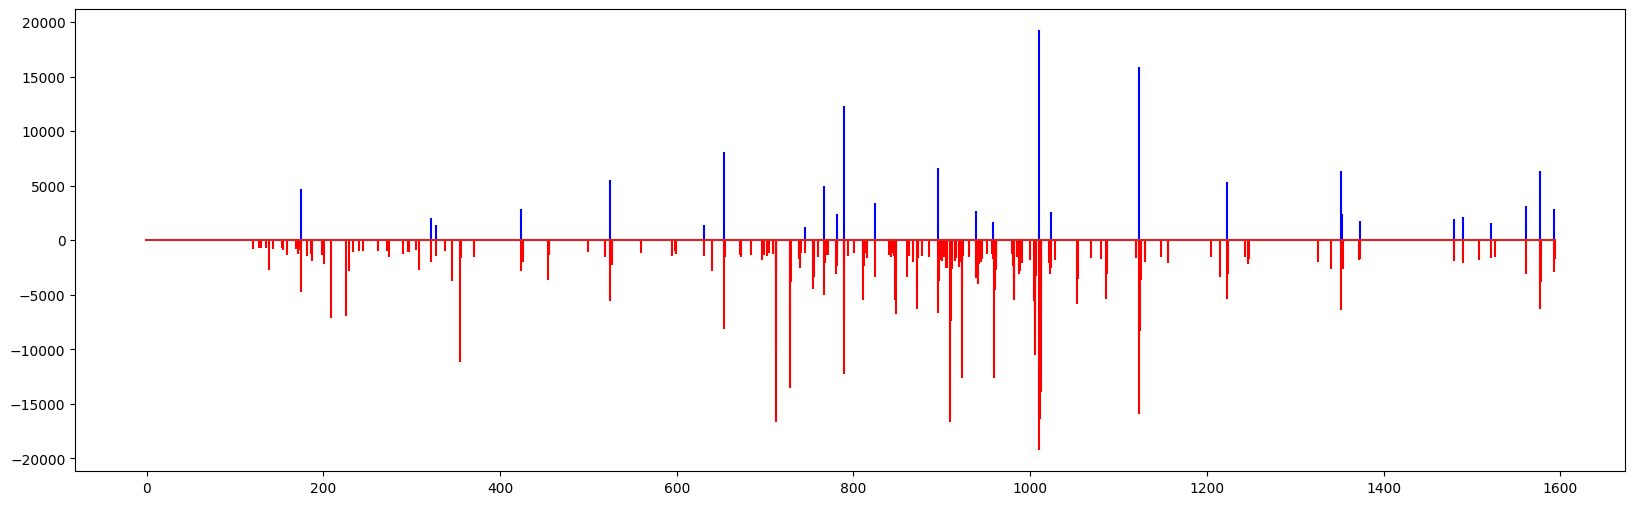

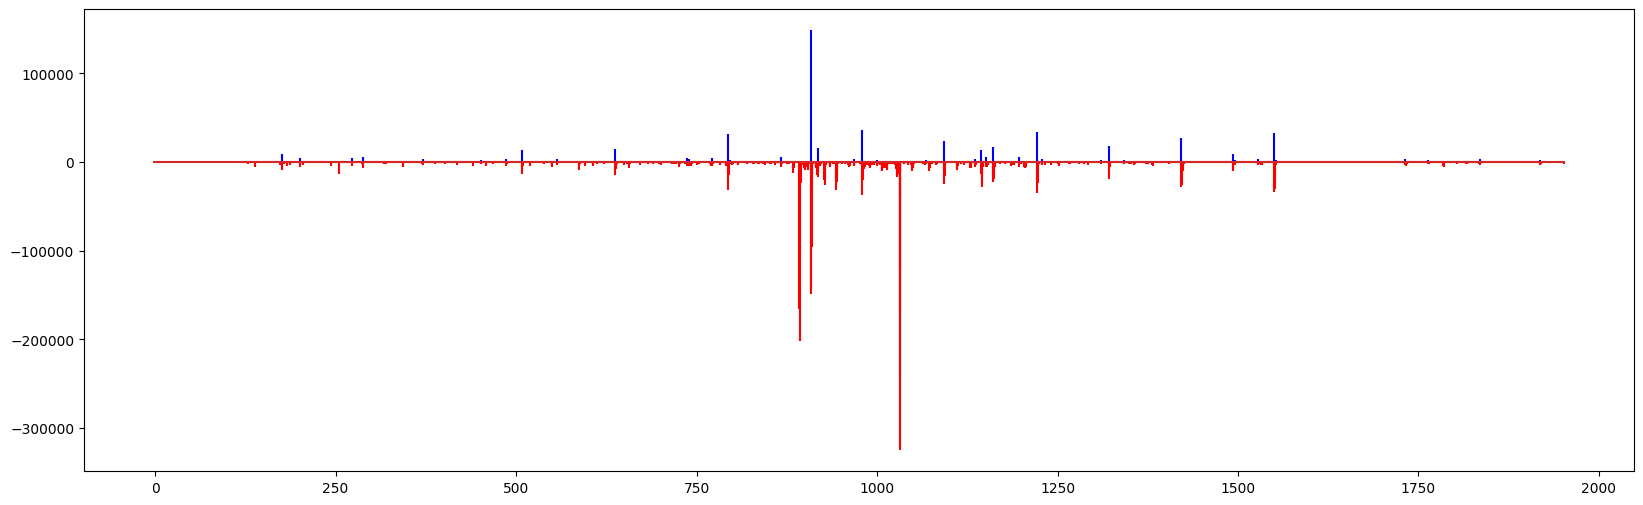

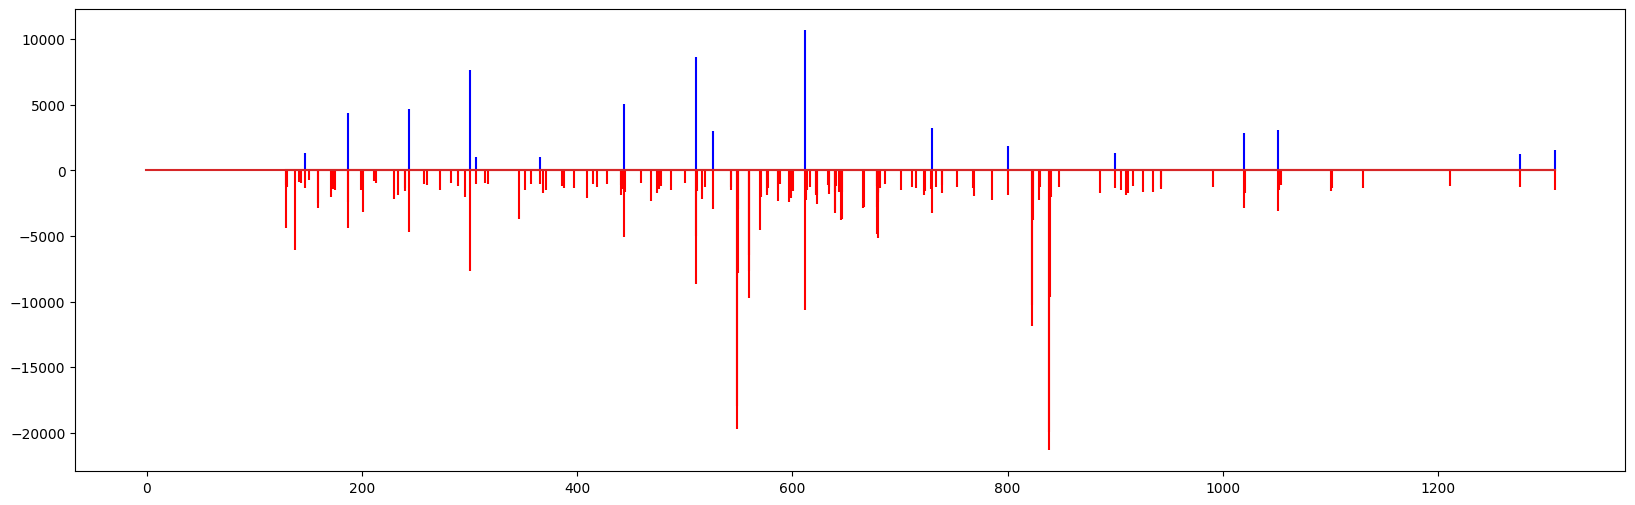

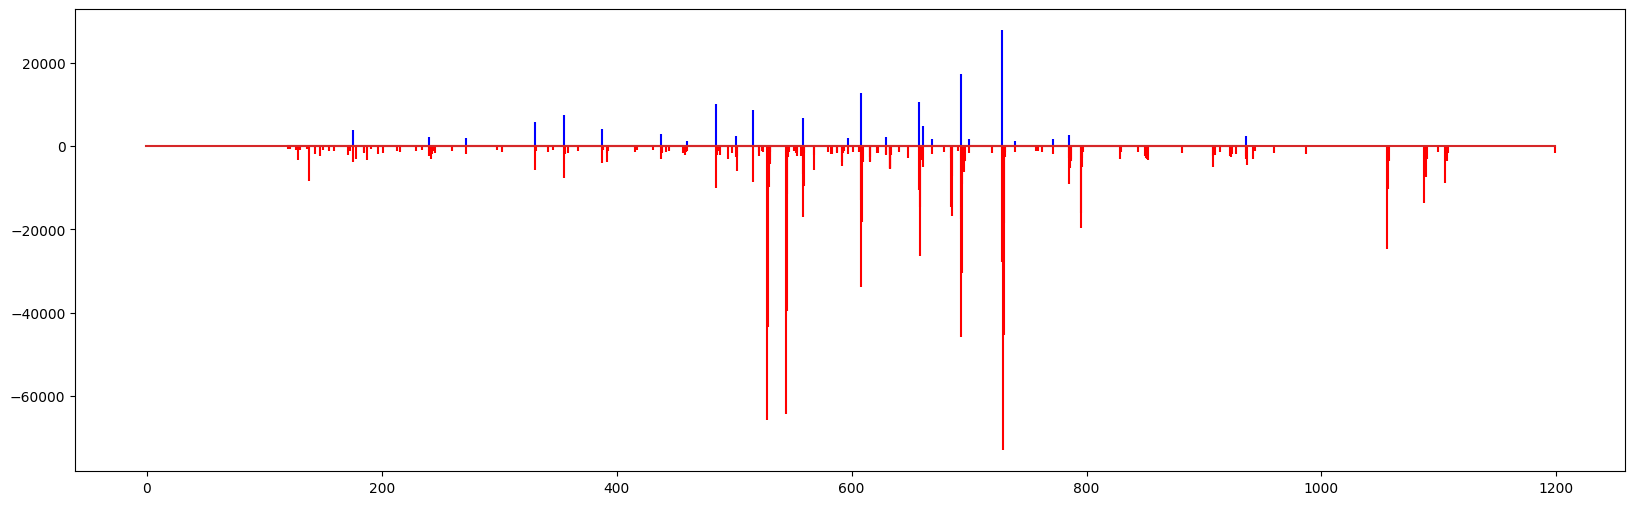

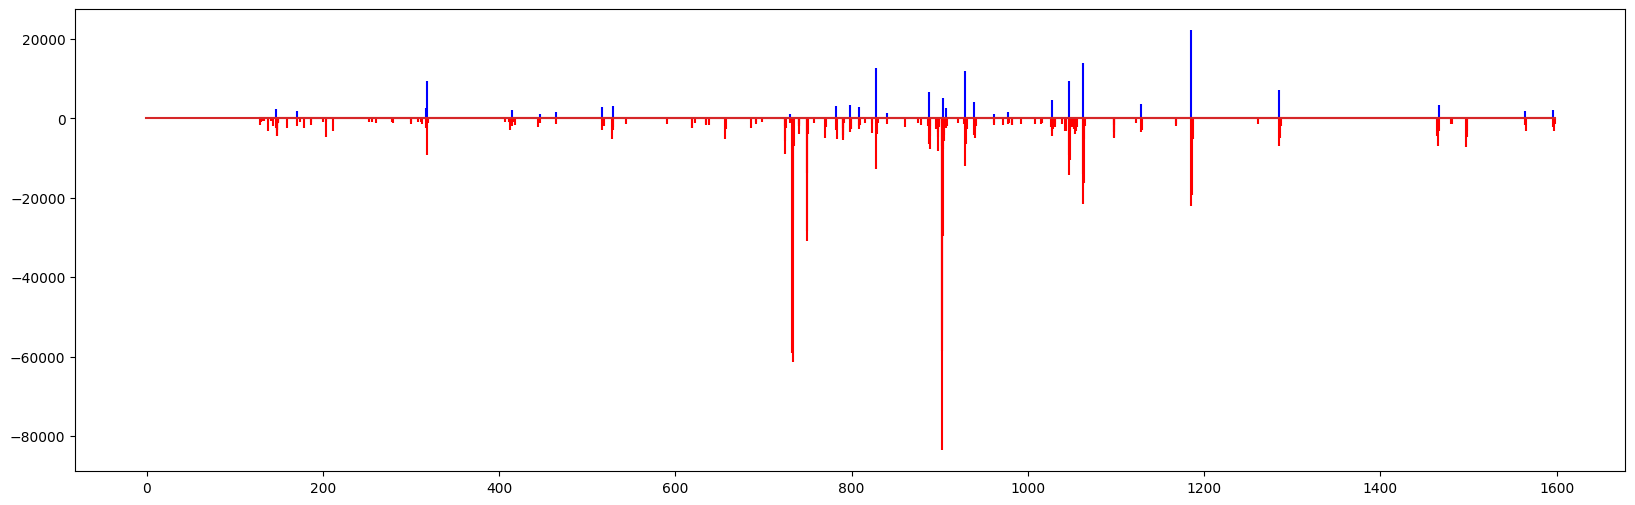

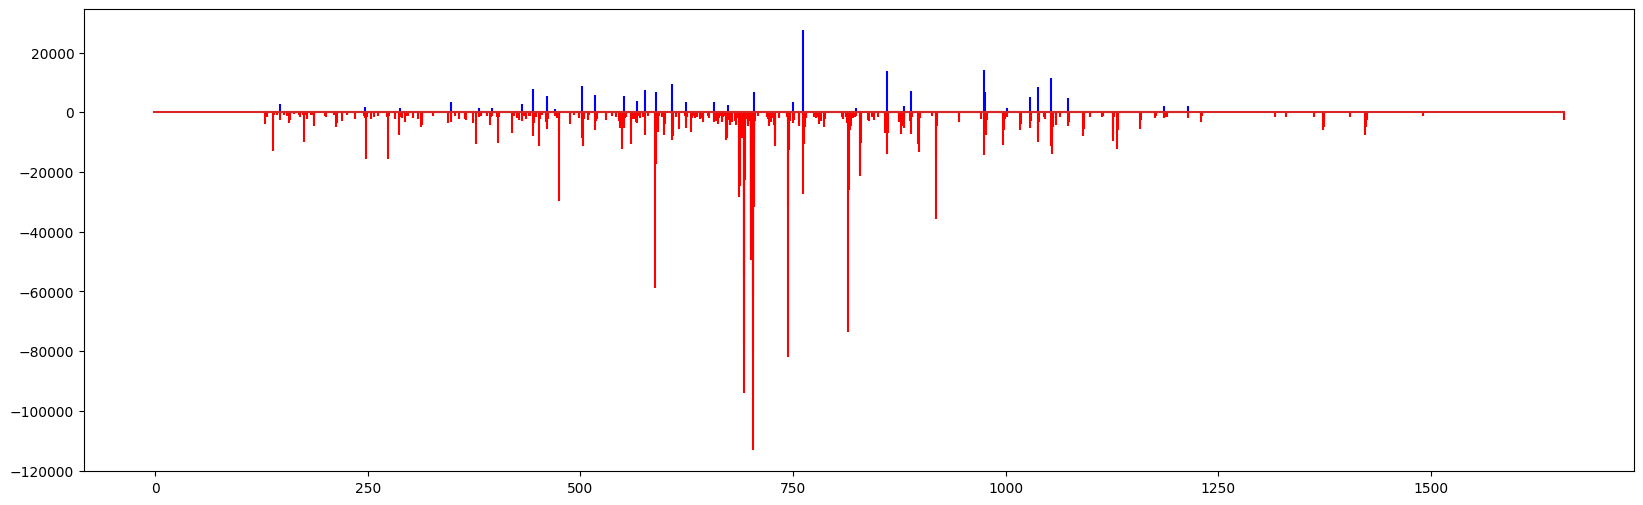

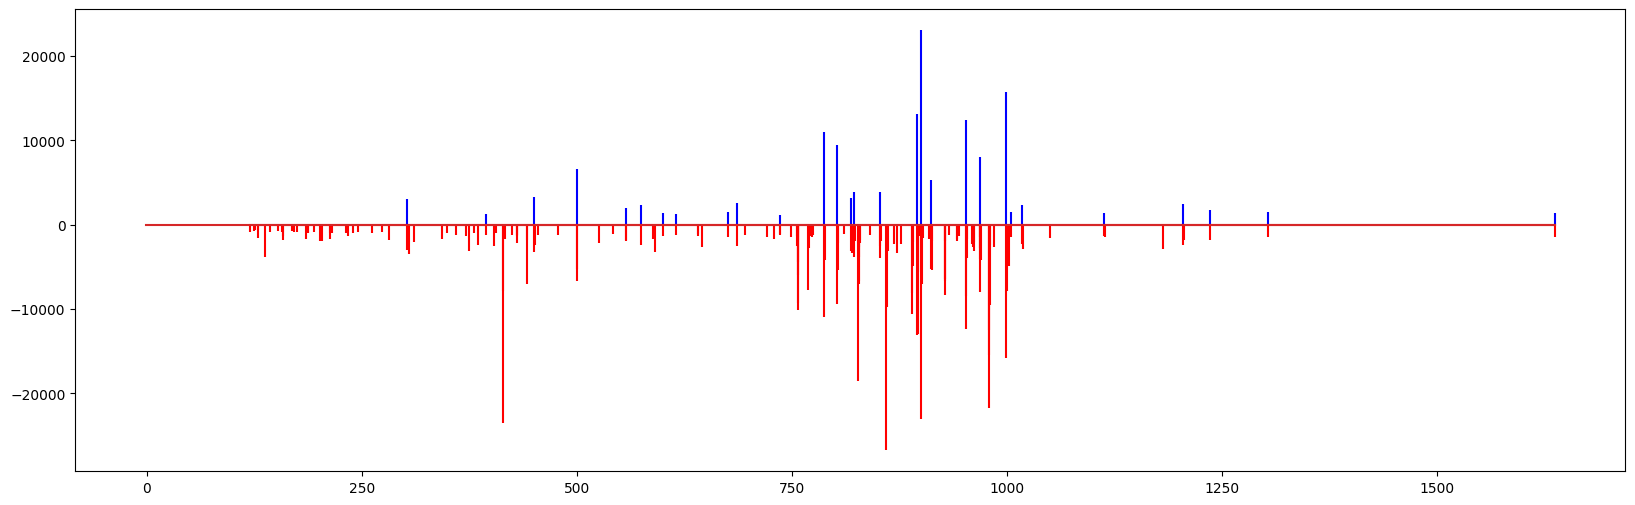

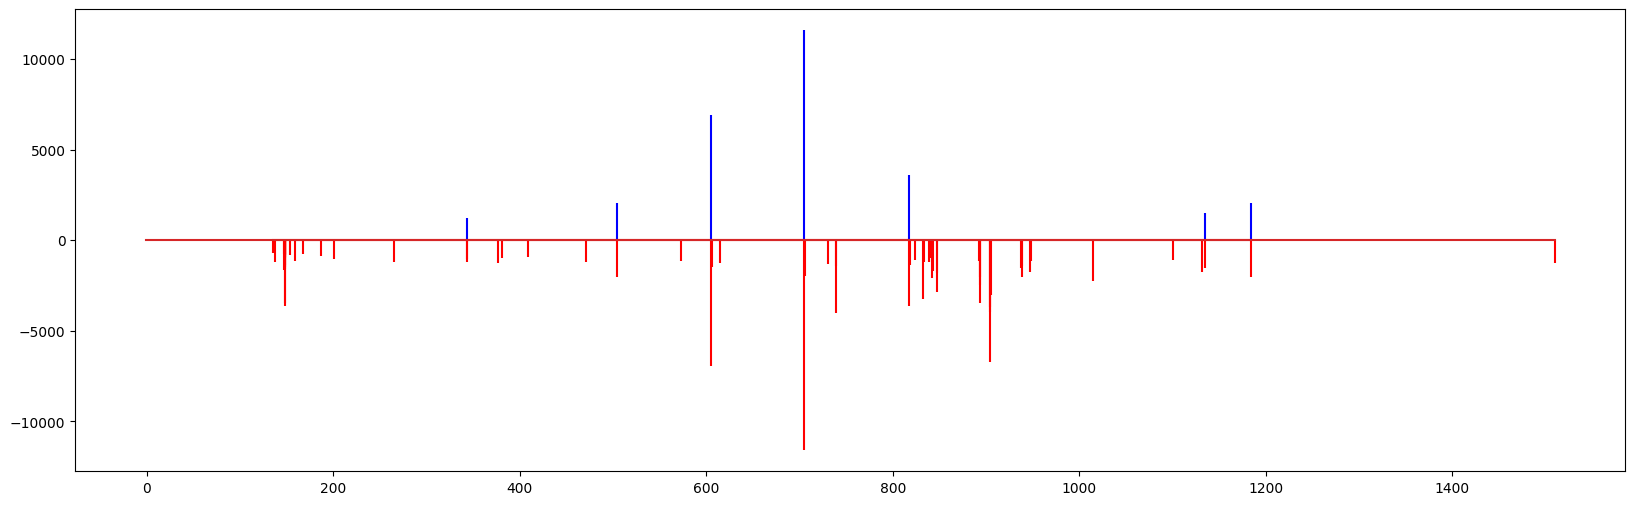

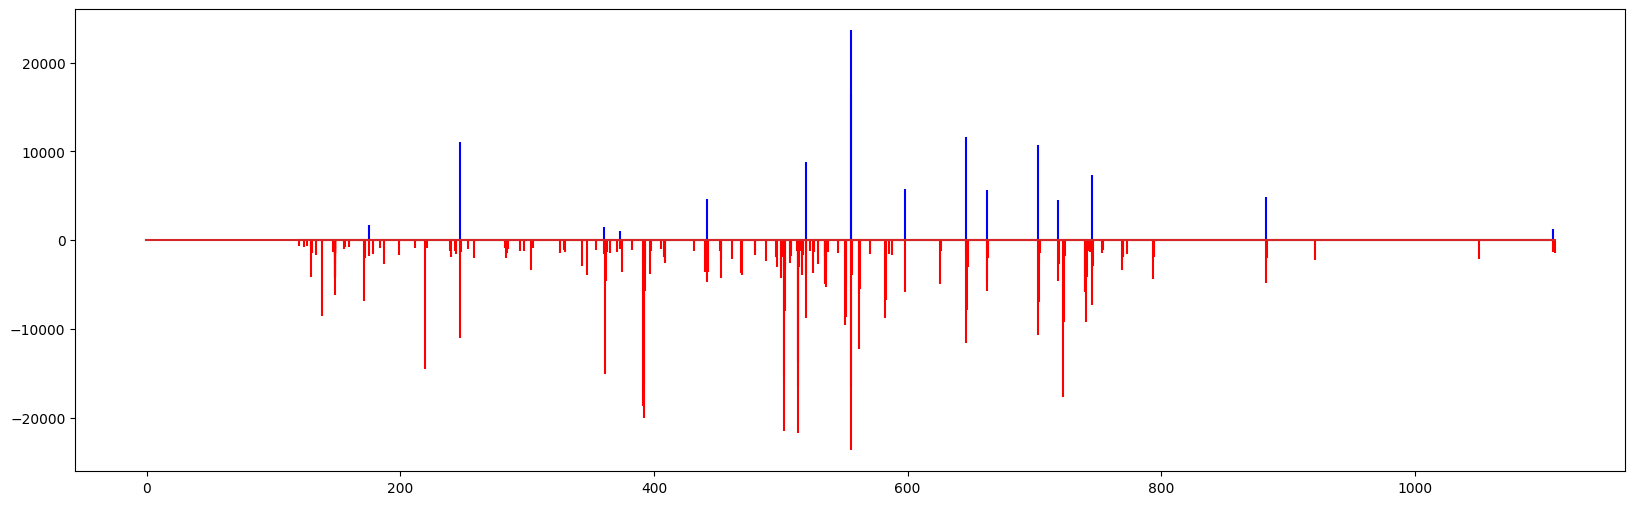

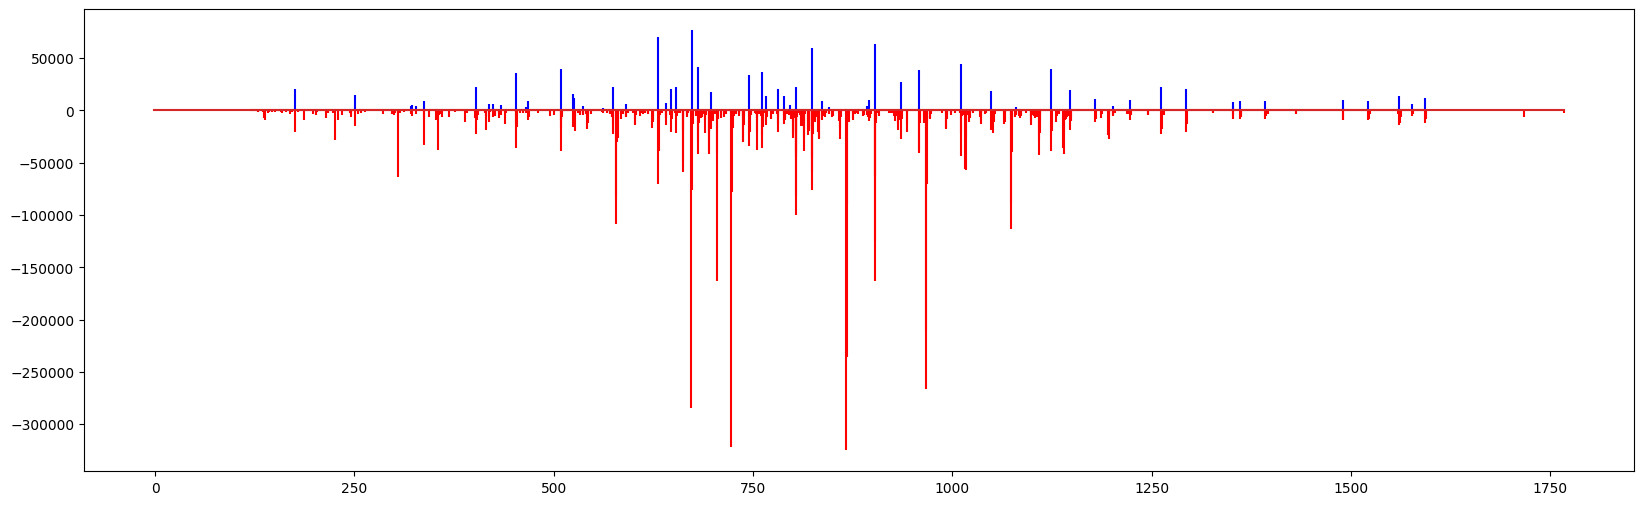

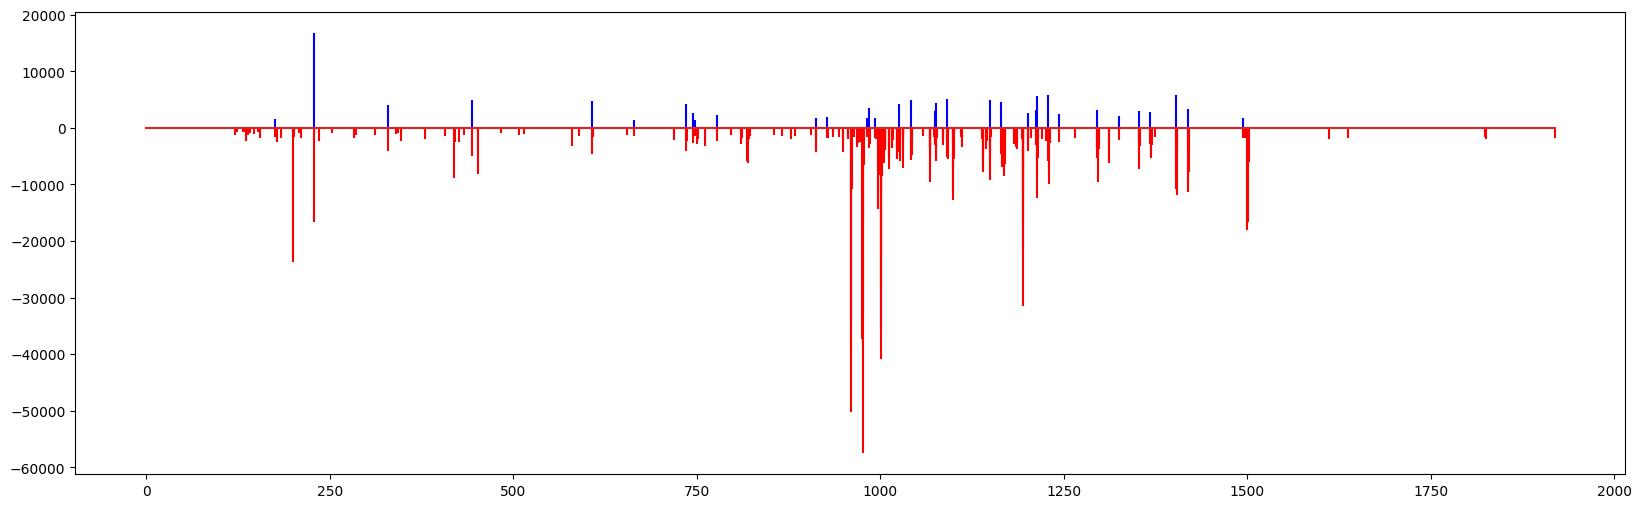

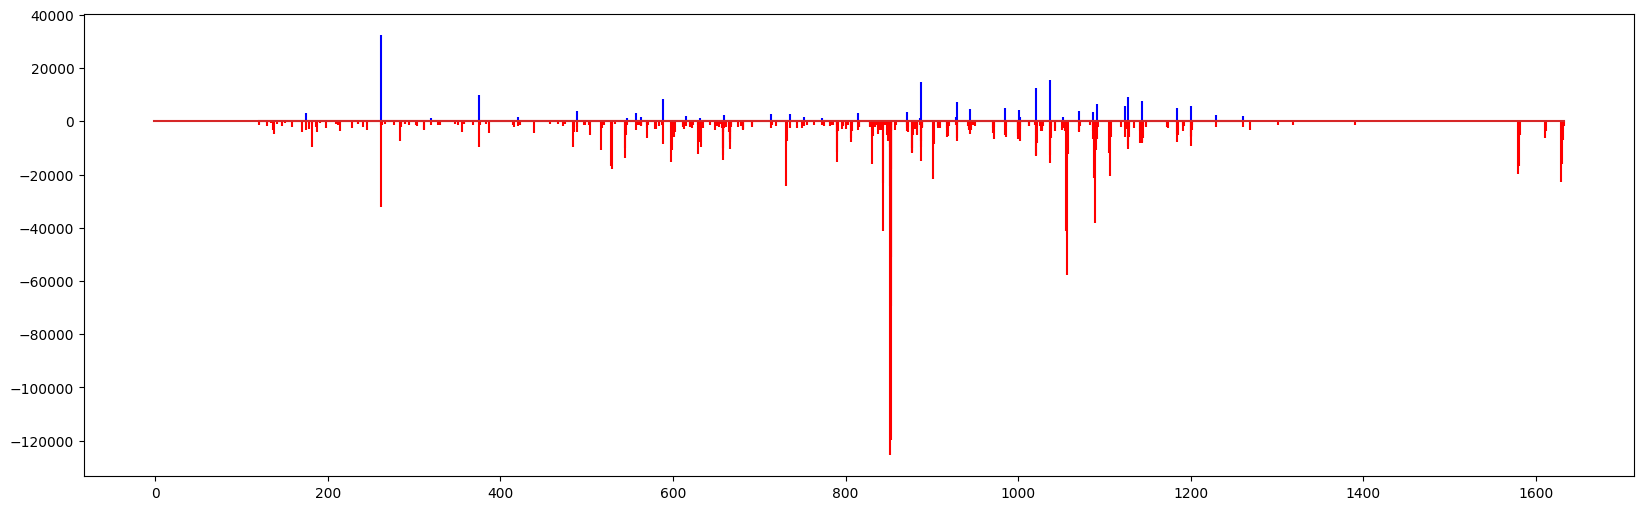

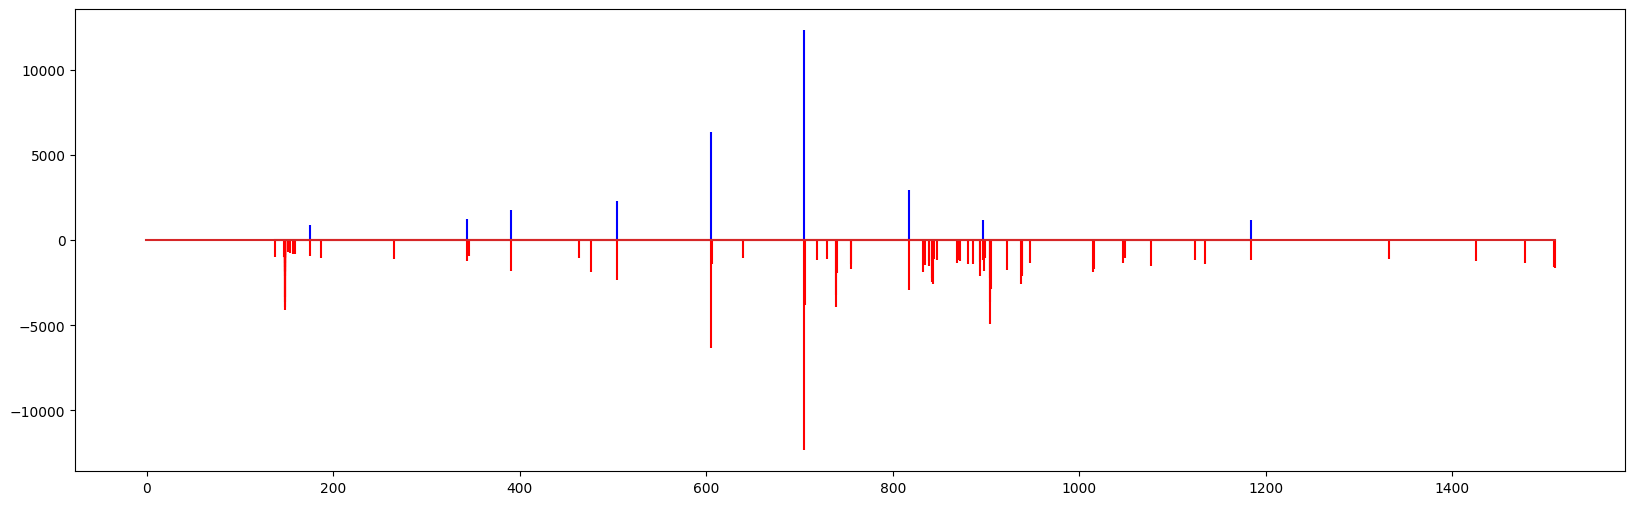

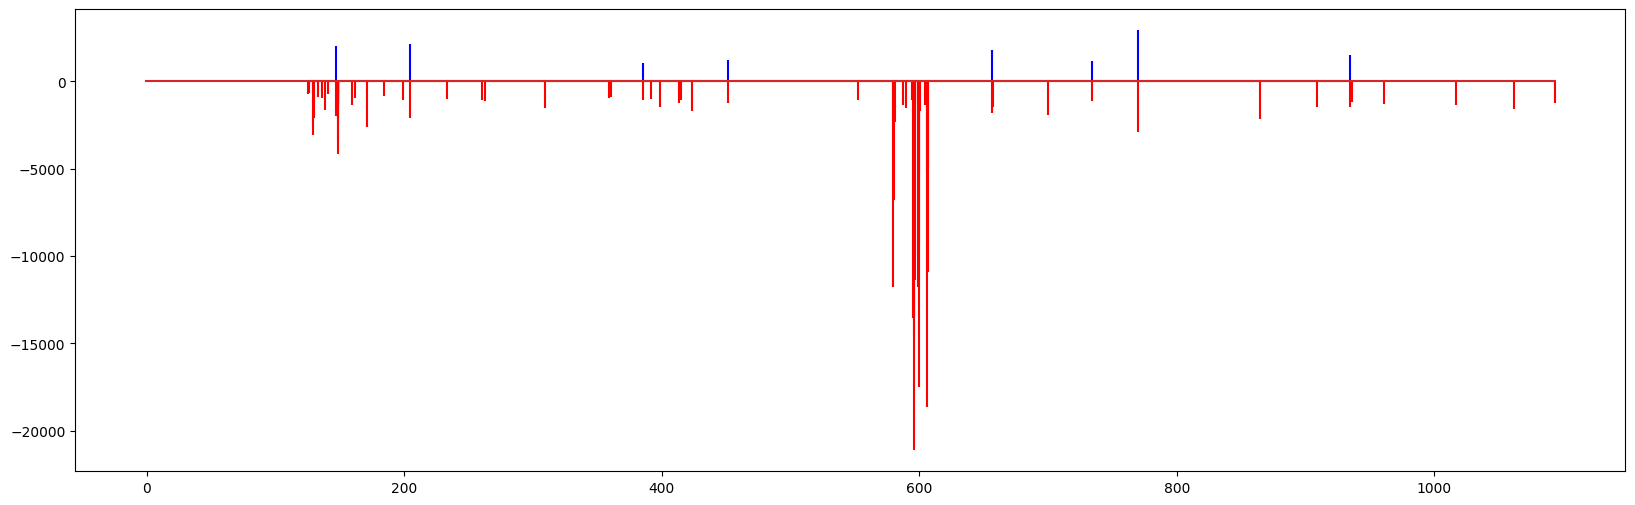

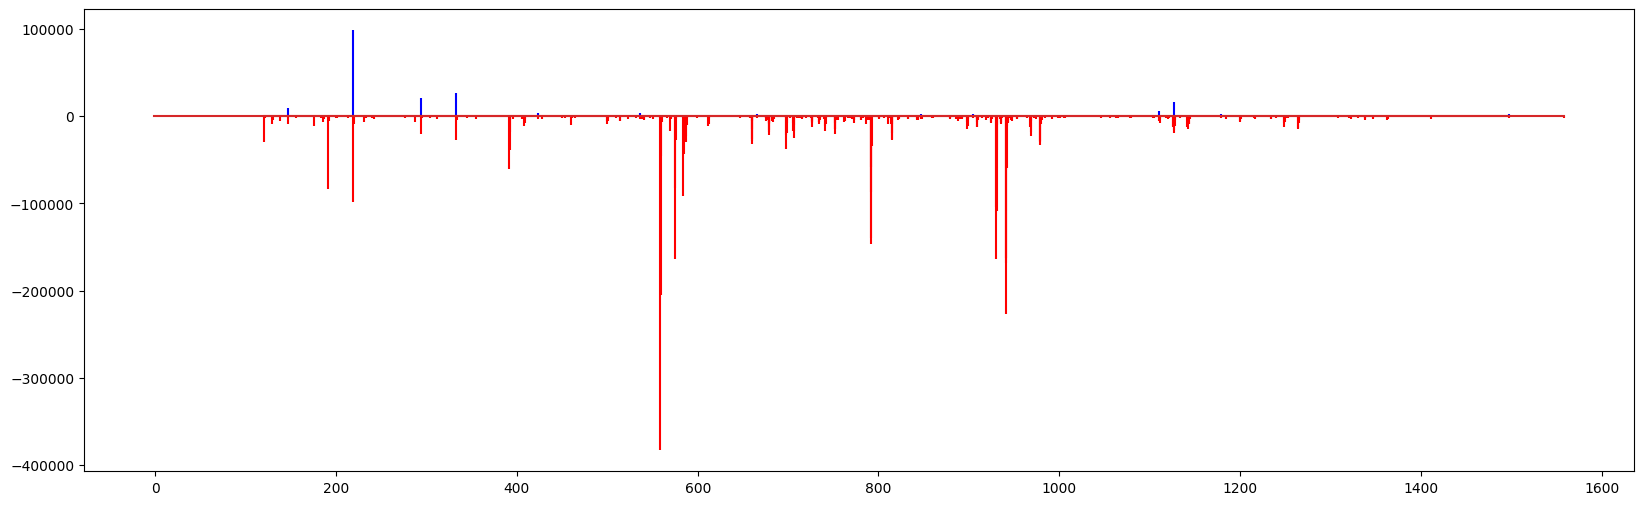

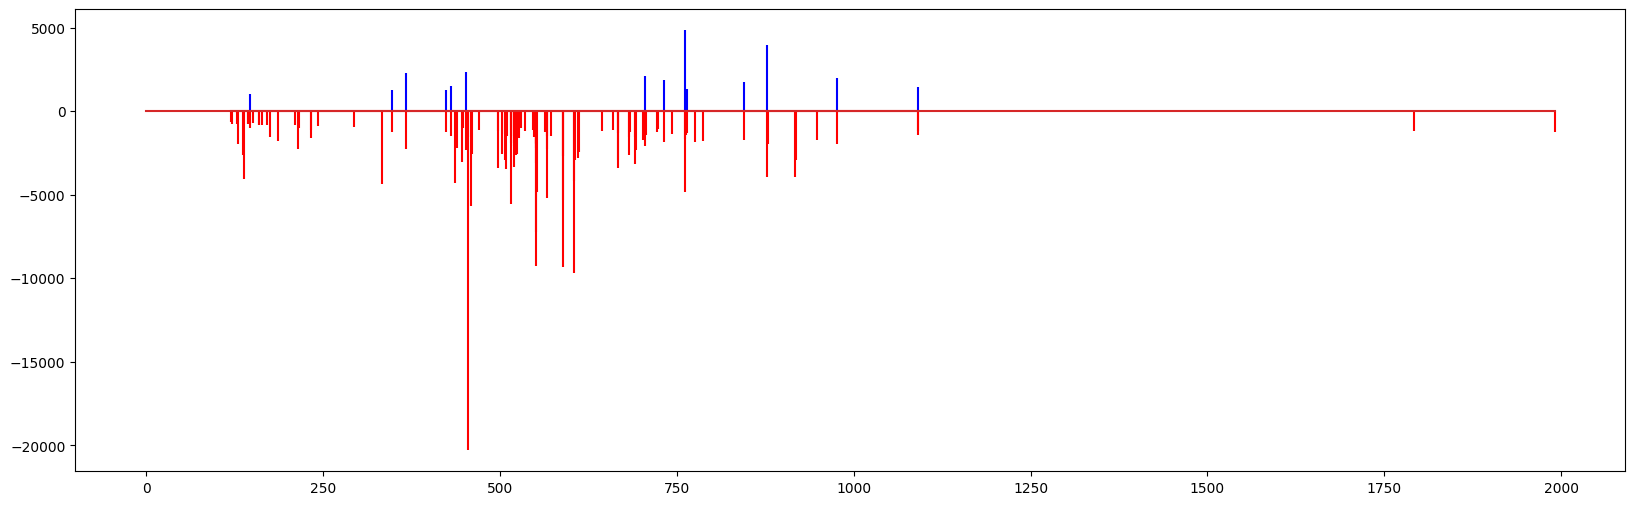

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#print(df_annotated_spectra['MZ'][519])
print(df_annotated_spectra['INTENSITIES'][519][174:])
#print(df_join['INTENSITIES'][519][0:5])
#print(df_join['CROSSLINKER_POSITION_A'][519])
print(df_join['MODIFIED_SEQUENCE_A'][519])
for i in range(820,840):
    plt.figure(figsize=(20, 6))
    plt.stem(df_annotated_spectra['MZ'][i], df_annotated_spectra['INTENSITIES'][i], linefmt='b',markerfmt='')
    plt.stem(df_join['MZ'][i], -df_join['INTENSITIES'][i], linefmt='r',markerfmt='')
    plt.show()
    



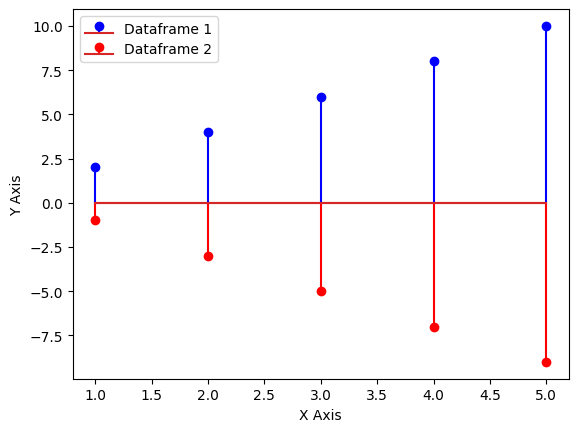

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# Example dataframes
df1 = pd.DataFrame({'x_column': [1, 2, 3, 4, 5], 'y_column': [2, 4, 6, 8, 10]})
df2 = pd.DataFrame({'x_column': [1, 2, 3, 4, 5], 'y_column': [1, 3, 5, 7, 9]})

# Plot the first dataframe
plt.stem(df1['x_column'], df1['y_column'], linefmt='b-', markerfmt='bo', label='Dataframe 1')

# Plot the second dataframe
plt.stem(df2['x_column'], -df2['y_column'], linefmt='r-', markerfmt='ro', label='Dataframe 2')

# Add labels and legend
plt.xlabel('X Axis')
plt.ylabel('Y Axis')
plt.legend()

# Show the plot
plt.show()


In [ ]:
import pandas as pd

#specific_string = "Lumos_RSLC8_steppedHCD_SEC_F2"
char1 = 'Lumos_RSLC8_steppedHCD_SEC_F2'
char2 = 'Lumos_RSLC8_steppedHCD_SEC_F4_1'
df = pd.read_csv("/home/mkalhor/wilhelmlab/notebooks/26SProteasome_Scerevisiae_2020.07.24.filtered_cross-linked_spectra_T.csv")
filtered_df = df[df['Title'].str.contains(f"{char1}")]
#filtered_df = df[df['Title'].str.contains(f"{char1}|{char2}")]
filtered_df.to_csv('filtered_data_1.csv', index=True)
display(filtered_df)
